# Model Graphs v2: Computation Market

## Model Environment

**Tasks** $i \in [0,1]$, ordered by complexity. **Workers** $f(i)$ at each task.

**CES production**: $Y = [\int y(i)^{(\sigma-1)/\sigma} di]^{\sigma/(\sigma-1)}$

**Pre-AI wage**: $w_0(i) = P_Y (Y_0 / f(i))^{1/\sigma}$ — scarce tasks pay more.

**AI capability**: $M(i) = (I^* - i)^\alpha$ for $i < I^*$, zero otherwise.
- $I^*$: capability frontier (where AI stops)
- $\alpha$: curvature. $\alpha > 1$: sharp dropoff near frontier. $\alpha < 1$: AI retains capability broadly.

**AI supply**: $s(i) = \gamma \cdot M(i) \cdot f(i)$
- $\gamma$: adoption intensity (scales everything proportionally)

**Post-AI**: $\bar{y}(i) = f(i) + s(i) = f(i)[1 + \gamma M(i)]$ for $i < I^*$

**Computation market** (Fig 6-7 only):
- Firm WTP at task $i$: $v(i) = M(i) \cdot w_0(i)$
- Monopolist: $TC = F + c \cdot Q$, sets $p^*$ via $MR = MC$
- Automated set: $\mathcal{A} = \{i : v(i) \geq p^*\}$ (can be disconnected)

## Parameters to tweak

| Param | Variable | What it does |
|---|---|---|
| `sigma` | $\sigma$ | CES substitution elasticity. Higher = tasks more substitutable |
| `I_star` | $I^*$ | AI frontier. Higher = AI can do more tasks |
| `alpha` | $\alpha$ | M(i) curvature. Higher = AI drops off faster near I* |
| `gamma` | $\gamma$ | Adoption intensity. Higher = more AI supply at every task |
| `f_bar` | $\bar{f}$ | f(i) intercept (workers at i=0) |
| `beta` | $\beta$ | f(i) slope: $f(i) = \bar{f}(1-\beta i)$ |
| `F_fixed` | $F$ | Monopolist fixed cost |
| `c_mc` | $c$ | Monopolist marginal cost (inference) |

**Fig 4 (steep f)** uses a separate `f_steep(i) = A * exp(-B * i) + floor`:
- `A` (first number): height at i=0. Bigger = more routine workers.
- `B` (decay rate): more negative = steeper drop. Try 6-12.
- `floor` (last number): minimum workers. Smaller = emptier at high i.

## Figures

- **Fig 1** `fig_preai.png` — pre-AI: f(i) and w_0(i)
- **Fig 2** `fig_postai.png` — post-AI for two gamma values (full automation, no monopoly cutoff)
- **Fig 3** `fig_capability.png` — expanding I*
- **Fig 4** `fig_multiple.png` — steep f(i) → disconnected automation set (uses monopoly)
- **Fig 5** `fig_M.png` — M(i) and s(i) for different alpha
- **Fig 6** `fig_computation_mkt.png` — demand curve Q(p), monopoly equilibrium, task-level WTP
- **Fig 7** `fig_comp_statics.png` — policy: tax (c up), antitrust (monopoly vs competitive), price cap

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
import os

os.makedirs('../output/model', exist_ok=True)

plt.rcParams.update({
    'font.family': 'serif',
    'font.size': 11,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

# ╔═══════════════════════════════════════════════════════════════════════════╗
# ║  EDIT ALL PARAMETERS HERE                                               ║
# ╚═══════════════════════════════════════════════════════════════════════════╝

# ── CES production ────────────────────────────────────────────────────────────
sigma   = 2.0          # elasticity of substitution

# ── Worker distribution: f(i) = f_bar * (1 - beta * i) ───────────────────────
f_bar   = 2.0          # intercept (workers at i=0)
beta    = 0.6          # slope (how fast f declines)

# ── AI capability: M(i) = (I* - i)^alpha ─────────────────────────────────────
I_star  = 0.4          # capability frontier
alpha   = 2         # curvature (>1: sharp dropoff near I*)

# ── Adoption ──────────────────────────────────────────────────────────────────
gamma   = 2.0          # adoption intensity

# ── Monopolist ────────────────────────────────────────────────────────────────
F_fixed = 0.5          # fixed cost (training, data centers)
c_mc    = 0.05         # marginal cost (inference)

# ── Fig 2: two gamma scenarios ────────────────────────────────────────────────
fig2_gammas = [1.0, 3.5]

# ── Fig 3: expanding frontier ─────────────────────────────────────────────────
fig3_Istars = [0.2, 0.4, 0.6]

# ── Fig 4: steep f(i) = A * exp(-B * i) + floor ──────────────────────────────
fig4_A     = 6.0       # height at i=0 (bigger = more routine workers)
fig4_B     = 6.0       # decay rate (bigger = steeper drop)
fig4_floor = 0.2       # minimum workers at high i
fig4_Istar = 0.7       # frontier for this figure

# ── Fig 5: alpha values to compare ───────────────────────────────────────────
fig5_alphas = [0.5, 1.0, 1.5, 2.5]

# ── Fig 7: policy scenarios ───────────────────────────────────────────────────
fig7_tax_cs     = [0.01, 0.05, 0.12]     # MC values for tax panel
fig7_cap_fracs  = [0.5, 1.5]             # price cap as fraction of p* and c

# ╔═══════════════════════════════════════════════════════════════════════════╗
# ║  BELOW: functions & pre-AI equilibrium (don't need to edit)             ║
# ╚═══════════════════════════════════════════════════════════════════════════╝

i_fine = np.linspace(0, 1, 2000)

def f_human(i, fb=f_bar, b=beta):
    return fb * (1.0 - b * np.asarray(i, dtype=float))

def M_cap(i, Is=I_star, a=alpha):
    i = np.asarray(i, dtype=float)
    return np.where(i < Is, np.maximum(0.0, Is - i)**a, 0.0)

def s_from_M(i, Is=I_star, a=alpha, g=gamma, fb=f_bar, b=beta):
    return g * M_cap(i, Is, a) * f_human(i, fb, b)

def compute_eq(supply_vals):
    int_Y = np.trapezoid(supply_vals**((sigma-1)/sigma), i_fine)
    return int_Y**(sigma/(sigma-1))

def wage_from_supply(Y, supply):
    return (Y / supply)**(1/sigma)

# Pre-AI
f_vals  = f_human(i_fine)
Y0      = compute_eq(f_vals)
w0_vals = wage_from_supply(Y0, f_vals)

# Computation market
M_vals = M_cap(i_fine)
v_vals = M_vals * w0_vals

def demand_curve(p_grid, v=v_vals, Mf=None):
    if Mf is None: Mf = M_vals * f_vals
    Q_out = np.zeros_like(p_grid)
    for j, p in enumerate(p_grid):
        mask = (v >= p) & (i_fine < I_star)
        Q_out[j] = gamma * np.trapezoid(Mf * mask, i_fine)
    return Q_out

def find_monopoly_price(c=c_mc, v=v_vals, Mf=None, Is=I_star, n_grid=300):
    if Mf is None: Mf = M_vals * f_vals
    v_pos = v[(i_fine < Is) & (v > 0)]
    if len(v_pos) == 0: return 0, 0, -F_fixed
    p_grid = np.linspace(0.001, v_pos.max() * 1.1, n_grid)
    Q_out = np.zeros(n_grid)
    for j, p in enumerate(p_grid):
        mask = (v >= p) & (i_fine < Is)
        Q_out[j] = gamma * np.trapezoid(Mf * mask, i_fine)
    pi = (p_grid - c) * Q_out - F_fixed
    idx = np.argmax(pi)
    return p_grid[idx], Q_out[idx], pi[idx]

p_star, Q_star, pi_star = find_monopoly_price()
auto_mask = (v_vals >= p_star) & (i_fine < I_star)
s_vals_eq = np.where(auto_mask, gamma * M_vals * f_vals, 0.0)
ybar_eq   = f_vals + s_vals_eq
Ybar_eq   = compute_eq(ybar_eq)
w1_eq     = wage_from_supply(Ybar_eq, ybar_eq)

print(f'sigma={sigma}, I*={I_star}, alpha={alpha}, gamma={gamma}')
print(f'Y0={Y0:.4f}, Ybar={Ybar_eq:.4f}')
print(f'Monopoly: p*={p_star:.4f}, Q*={Q_star:.4f}, pi*={pi_star:.4f}')

sigma=2.0, I*=0.4, alpha=4, gamma=2.0
Y0=1.3779, Ybar=1.3779
Monopoly: p*=0.0213, Q*=0.0000, pi*=-0.5000


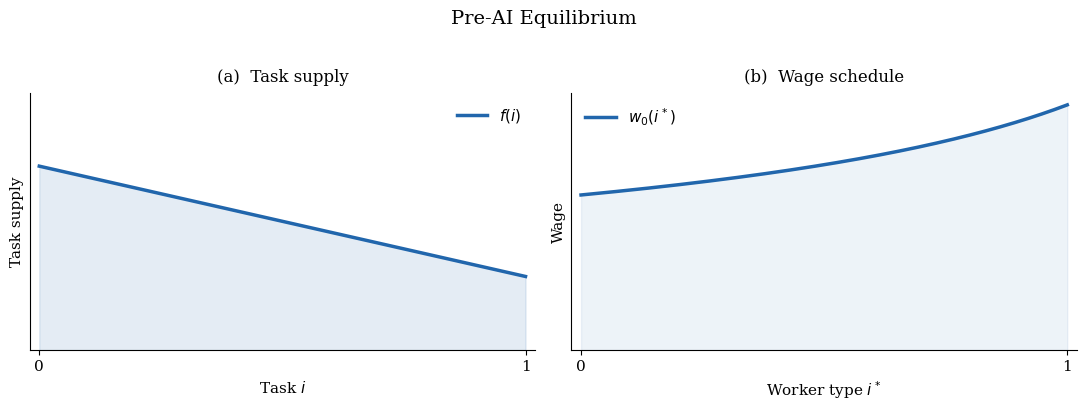

In [56]:
# ── Figure 1: Pre-AI ──────────────────────────────────────────────────────────
fig, (ax_s, ax_w) = plt.subplots(1, 2, figsize=(11, 4))

ax_s.fill_between(i_fine, 0, f_vals, alpha=0.12, color='#2166ac')
ax_s.plot(i_fine, f_vals, color='#2166ac', lw=2.5, label=r'$f(i)$')
ax_s.set_xlabel(r'Task $i$'); ax_s.set_ylabel('Task supply')
ax_s.set_title('(a)  Task supply', fontsize=12, pad=8)
ax_s.set_xlim(-0.02, 1.02); ax_s.set_ylim(0, 2.8)
ax_s.set_xticks([0,1]); ax_s.set_yticks([])
ax_s.legend(fontsize=11, framealpha=0, loc='upper right')

ax_w.plot(i_fine, w0_vals, color='#2166ac', lw=2.5, label=r'$w_0(i^*)$')
ax_w.fill_between(i_fine, 0, w0_vals, alpha=0.08, color='#2166ac')
ax_w.set_xlabel(r'Worker type $i^*$'); ax_w.set_ylabel('Wage')
ax_w.set_title('(b)  Wage schedule', fontsize=12, pad=8)
ax_w.set_xlim(-0.02, 1.02); ax_w.set_ylim(0)
ax_w.set_xticks([0,1]); ax_w.set_yticks([])
ax_w.legend(fontsize=11, framealpha=0, loc='upper left')

fig.suptitle('Pre-AI Equilibrium', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../output/model/fig_preai.png', dpi=150, bbox_inches='tight')
plt.show()

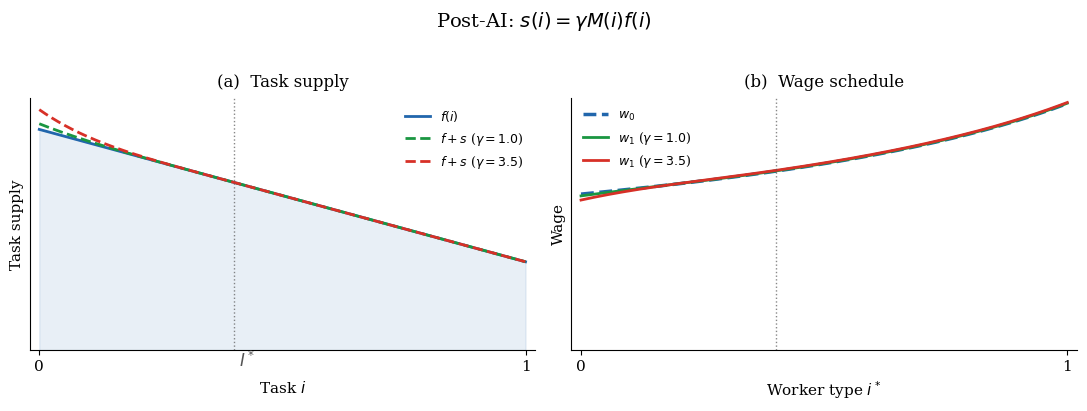

In [57]:
# ── Figure 2: Post-AI (two gamma) ────────────────────────────────────────────
g_colors = ['#1a9641', '#d73027']

fig, (ax_s, ax_w) = plt.subplots(1, 2, figsize=(11, 4))

ax_s.fill_between(i_fine, 0, f_vals, alpha=0.10, color='#2166ac')
ax_s.plot(i_fine, f_vals, color='#2166ac', lw=2, label=r'$f(i)$')
for g, col in zip(fig2_gammas, g_colors):
    ybar = f_vals + s_from_M(i_fine, g=g)
    ax_s.plot(i_fine, ybar, color=col, lw=2, ls='--', label=rf'$f+s$ ($\gamma={g}$)')
ax_s.axvline(I_star, color='#555555', lw=1, ls=':', alpha=0.7)
ax_s.annotate(r'$I^*$', xy=(I_star,0), xytext=(I_star+0.01,-0.15),
              ha='left', fontsize=12, color='#555555', annotation_clip=False)
ax_s.set_xlabel(r'Task $i$'); ax_s.set_ylabel('Task supply')
ax_s.set_title('(a)  Task supply', fontsize=12, pad=8)
ax_s.set_xlim(-0.02, 1.02); ax_s.set_ylim(0)
ax_s.set_xticks([0,1]); ax_s.set_yticks([])
ax_s.legend(fontsize=9, framealpha=0, loc='upper right')

ax_w.plot(i_fine, w0_vals, color='#2166ac', lw=2.5, ls='--', label=r'$w_0$')
for g, col in zip(fig2_gammas, g_colors):
    yb = f_vals + s_from_M(i_fine, g=g)
    Yb = compute_eq(yb); w1 = wage_from_supply(Yb, yb)
    ax_w.plot(i_fine, w1, color=col, lw=2, label=rf'$w_1$ ($\gamma={g}$)')
ax_w.axvline(I_star, color='#555555', lw=1, ls=':', alpha=0.7)
ax_w.set_xlabel(r'Worker type $i^*$'); ax_w.set_ylabel('Wage')
ax_w.set_title('(b)  Wage schedule', fontsize=12, pad=8)
ax_w.set_xlim(-0.02, 1.02); ax_w.set_ylim(0)
ax_w.set_xticks([0,1]); ax_w.set_yticks([])
ax_w.legend(fontsize=9, framealpha=0, loc='upper left')

fig.suptitle(r'Post-AI: $s(i) = \gamma M(i) f(i)$', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../output/model/fig_postai.png', dpi=150, bbox_inches='tight')
plt.show()

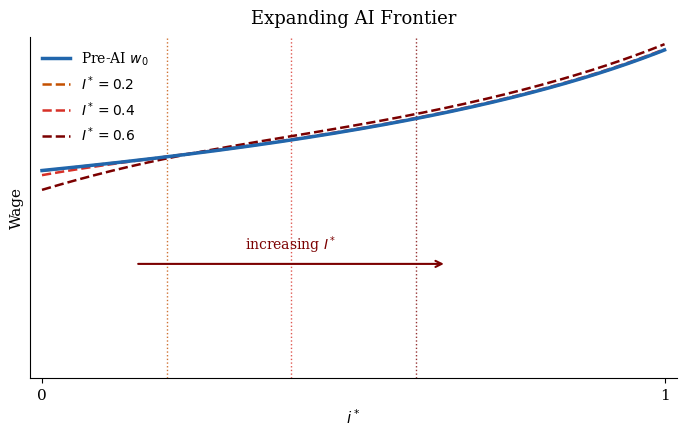

In [58]:
# ── Figure 3: Expanding frontier ──────────────────────────────────────────────
cap_colors = ['#c45000', '#d73027', '#7b0000']

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.plot(i_fine, w0_vals, color='#2166ac', lw=2.5, label=r'Pre-AI $w_0$', zorder=5)
for Is, col in zip(fig3_Istars, cap_colors):
    yb = f_vals + s_from_M(i_fine, Is=Is)
    Yb = compute_eq(yb); w1 = wage_from_supply(Yb, yb)
    ax.plot(i_fine, w1, color=col, lw=1.8, ls='--', label=rf'$I^*={Is}$')
    ax.axvline(Is, color=col, lw=1.0, ls=':', alpha=0.8)
ax.annotate('', xy=(0.65, w0_vals.min()*0.55), xytext=(0.15, w0_vals.min()*0.55),
            arrowprops=dict(arrowstyle='->', color='#7b0000', lw=1.5))
ax.text(0.40, w0_vals.min()*0.62, r'increasing $I^*$', fontsize=10, color='#7b0000', ha='center')
ax.set_xlabel(r'$i^*$'); ax.set_ylabel('Wage')
ax.set_title('Expanding AI Frontier', fontsize=13, pad=10)
ax.set_xlim(-0.02, 1.02); ax.set_ylim(0)
ax.set_xticks([0,1]); ax.set_yticks([])
ax.legend(fontsize=10, framealpha=0, loc='upper left')
plt.tight_layout()
plt.savefig('../output/model/fig_capability.png', dpi=150, bbox_inches='tight')
plt.show()

Fig4: p*=0.0743, automated: 134/1400


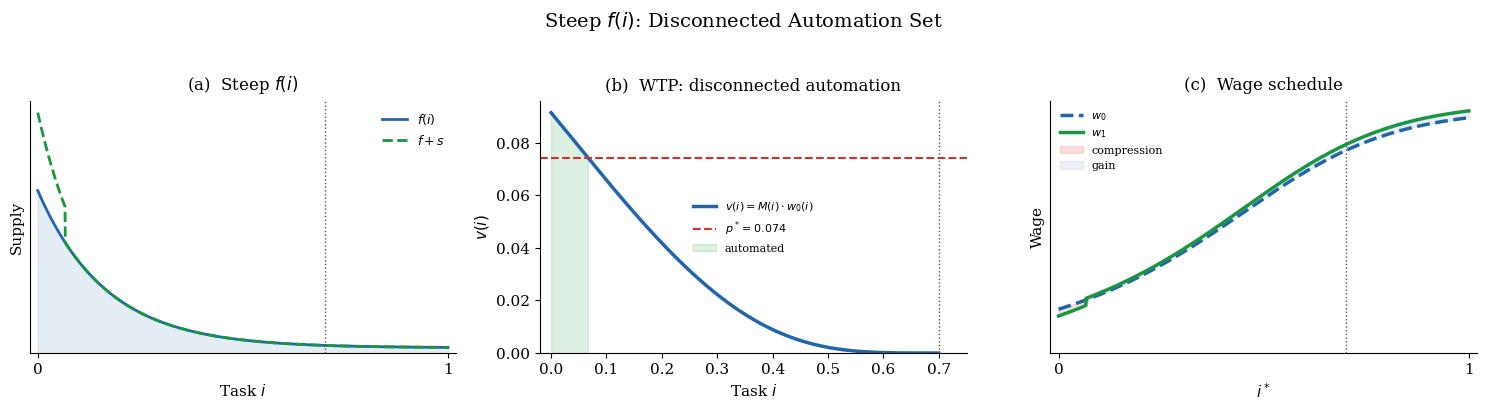

In [59]:
# ── Figure 4: Steep f(i) → disconnected automation set ────────────────────────
def f_steep(i):
    i = np.asarray(i, dtype=float)
    return fig4_A * np.exp(-fig4_B * i) + fig4_floor

f_st = f_steep(i_fine)
Y0_st = compute_eq(f_st)
w0_st = wage_from_supply(Y0_st, f_st)

M_st = M_cap(i_fine, Is=fig4_Istar)
v_st = M_st * w0_st
Mf_st = M_st * f_st

def demand_curve_st(p_grid):
    Q_out = np.zeros_like(p_grid)
    for j, p in enumerate(p_grid):
        mask = (v_st >= p) & (i_fine < fig4_Istar)
        Q_out[j] = gamma * np.trapezoid(Mf_st * mask, i_fine)
    return Q_out

pg = np.linspace(0.001, v_st[(i_fine < fig4_Istar) & (v_st > 0)].max() * 1.1, 300)
Qg = demand_curve_st(pg)
pig = (pg - c_mc) * Qg - F_fixed
p_st = pg[np.argmax(pig)]

auto_mask_st = (v_st >= p_st) & (i_fine < fig4_Istar)
s_st = np.where(auto_mask_st, gamma * M_st * f_st, 0.0)
ybar_st = f_st + s_st
Ybar_st = compute_eq(ybar_st)
w1_st = wage_from_supply(Ybar_st, ybar_st)

print(f'Fig4: p*={p_st:.4f}, automated: {auto_mask_st.sum()}/{(i_fine<fig4_Istar).sum()}')

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

ax = axes[0]
ax.fill_between(i_fine, 0, f_st, alpha=0.12, color='#2166ac')
ax.plot(i_fine, f_st, color='#2166ac', lw=2, label=r'$f(i)$')
ax.plot(i_fine, ybar_st, color='#1a9641', lw=2, ls='--', label=r'$f + s$')
ax.axvline(fig4_Istar, color='#555555', lw=1, ls=':')
ax.set_xlabel(r'Task $i$'); ax.set_ylabel('Supply')
ax.set_title('(a)  Steep $f(i)$', fontsize=12, pad=8)
ax.set_xlim(-0.02, 1.02); ax.set_ylim(0)
ax.set_xticks([0, 1]); ax.set_yticks([])
ax.legend(fontsize=9, framealpha=0, loc='upper right')

ax = axes[1]
i_mask = i_fine < fig4_Istar
ax.plot(i_fine[i_mask], v_st[i_mask], color='#2166ac', lw=2.5,
        label=r'$v(i) = M(i) \cdot w_0(i)$')
ax.axhline(p_st, color='#d73027', lw=1.5, ls='--', label=f'$p^*={p_st:.3f}$')
ax.fill_between(i_fine[i_mask], 0, v_st[i_mask],
                where=auto_mask_st[i_mask],
                alpha=0.15, color='#1a9641', label='automated')
ax.axvline(fig4_Istar, color='#555555', lw=1, ls=':')
ax.set_xlabel(r'Task $i$'); ax.set_ylabel(r'$v(i)$')
ax.set_title('(b)  WTP: disconnected automation', fontsize=12, pad=8)
ax.set_xlim(-0.02, fig4_Istar + 0.05); ax.set_ylim(0)
ax.legend(fontsize=8, framealpha=0)

ax = axes[2]
ax.plot(i_fine, w0_st, color='#2166ac', lw=2.5, ls='--', label=r'$w_0$')
ax.plot(i_fine, w1_st, color='#1a9641', lw=2.5, label=r'$w_1$')
ax.fill_between(i_fine, w1_st, w0_st, where=(w1_st < w0_st),
                alpha=0.15, color='#d73027', label='compression')
ax.fill_between(i_fine, w0_st, w1_st, where=(w1_st > w0_st),
                alpha=0.10, color='#4575b4', label='gain')
ax.axvline(fig4_Istar, color='#555555', lw=1, ls=':')
ax.set_xlabel(r'$i^*$'); ax.set_ylabel('Wage')
ax.set_title('(c)  Wage schedule', fontsize=12, pad=8)
ax.set_xlim(-0.02, 1.02); ax.set_ylim(0)
ax.set_xticks([0, 1]); ax.set_yticks([])
ax.legend(fontsize=8, framealpha=0, loc='upper left')

fig.suptitle('Steep $f(i)$: Disconnected Automation Set', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../output/model/fig_multiple.png', dpi=150, bbox_inches='tight')
plt.show()

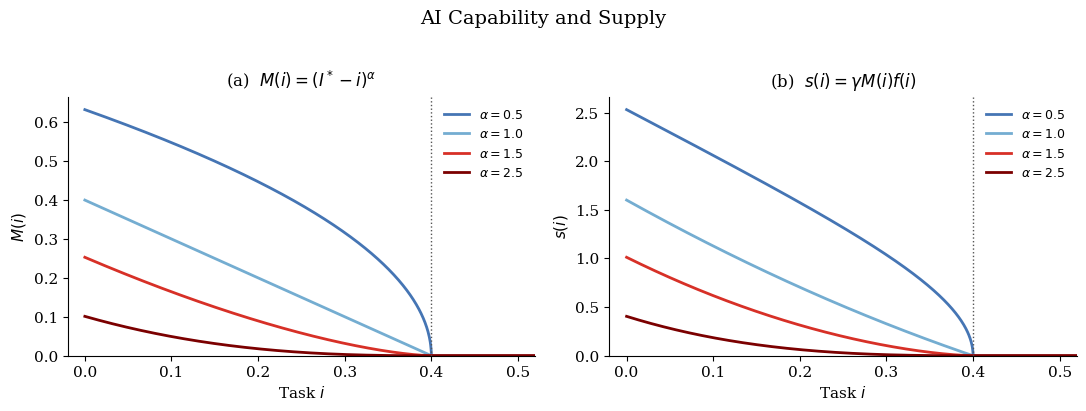

In [60]:
# ── Figure 5: M(i) and s(i) ──────────────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))
a_colors = ['#4575b4', '#74add1', '#d73027', '#7b0000']

for a, col in zip(fig5_alphas, a_colors):
    ax1.plot(i_fine, M_cap(i_fine, a=a), color=col, lw=2, label=rf'$\alpha={a}$')
ax1.axvline(I_star, color='#555555', lw=1, ls=':')
ax1.set_xlabel(r'Task $i$'); ax1.set_ylabel(r'$M(i)$')
ax1.set_title(r'(a)  $M(i) = (I^*-i)^\alpha$', fontsize=12, pad=8)
ax1.set_xlim(-0.02, 0.52); ax1.set_ylim(0)
ax1.legend(fontsize=9, framealpha=0)

for a, col in zip(fig5_alphas, a_colors):
    ax2.plot(i_fine, gamma * M_cap(i_fine, a=a) * f_vals, color=col, lw=2, label=rf'$\alpha={a}$')
ax2.axvline(I_star, color='#555555', lw=1, ls=':')
ax2.set_xlabel(r'Task $i$'); ax2.set_ylabel(r'$s(i)$')
ax2.set_title(r'(b)  $s(i) = \gamma M(i) f(i)$', fontsize=12, pad=8)
ax2.set_xlim(-0.02, 0.52); ax2.set_ylim(0)
ax2.legend(fontsize=9, framealpha=0)

fig.suptitle('AI Capability and Supply', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../output/model/fig_M.png', dpi=150, bbox_inches='tight')
plt.show()

c:\Users\Terry\miniconda3\envs\econ_env\Lib\site-packages\numpy\lib\_function_base_impl.py:1317: RuntimeWarning: invalid value encountered in divide
  a = -(dx2) / (dx1 * (dx1 + dx2))
c:\Users\Terry\miniconda3\envs\econ_env\Lib\site-packages\numpy\lib\_function_base_impl.py:1318: RuntimeWarning: divide by zero encountered in divide
  b = (dx2 - dx1) / (dx1 * dx2)
c:\Users\Terry\miniconda3\envs\econ_env\Lib\site-packages\numpy\lib\_function_base_impl.py:1318: RuntimeWarning: invalid value encountered in divide
  b = (dx2 - dx1) / (dx1 * dx2)
c:\Users\Terry\miniconda3\envs\econ_env\Lib\site-packages\numpy\lib\_function_base_impl.py:1319: RuntimeWarning: divide by zero encountered in divide
  c = dx1 / (dx2 * (dx1 + dx2))
c:\Users\Terry\miniconda3\envs\econ_env\Lib\site-packages\numpy\lib\_function_base_impl.py:1319: RuntimeWarning: invalid value encountered in divide
  c = dx1 / (dx2 * (dx1 + dx2))
c:\Users\Terry\miniconda3\envs\econ_env\Lib\site-packages\numpy\lib\_function_base_impl.py

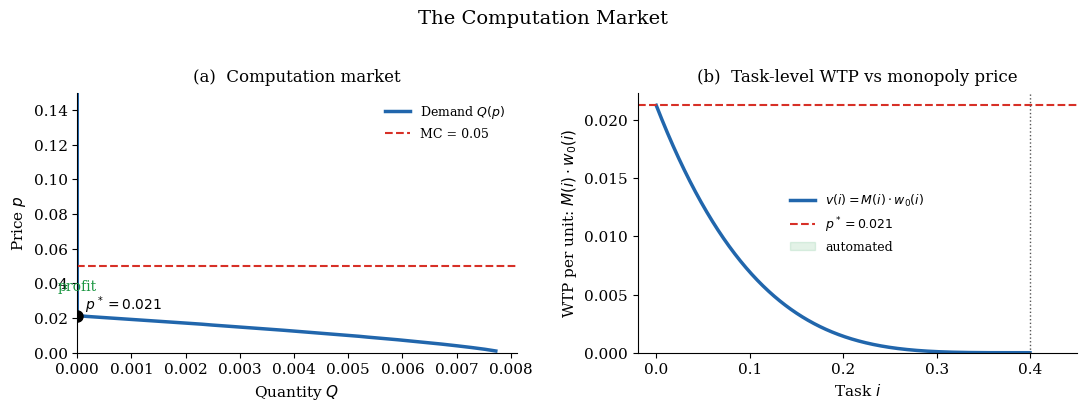

p*=0.0213, Q*=0.0000, pi*=-0.5000


In [61]:
# ── Figure 6: Computation market ──────────────────────────────────────────────
p_grid = np.linspace(0.001, 0.15, 300)
Q_grid = demand_curve(p_grid)

# Revenue and marginal revenue (numerical)
R_grid = p_grid * Q_grid
MR_grid = np.gradient(R_grid, Q_grid)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

# (a) Demand curve with monopoly equilibrium
ax1.plot(Q_grid, p_grid, color='#2166ac', lw=2.5, label='Demand $Q(p)$')
ax1.axhline(c_mc, color='#d73027', lw=1.5, ls='--', label=f'MC = {c_mc}')
ax1.plot(Q_star, p_star, 'ko', ms=8, zorder=5)
ax1.annotate(f'  $p^*={p_star:.3f}$', xy=(Q_star, p_star),
             fontsize=10, va='bottom')

# Shade profit rectangle
ax1.fill_between([0, Q_star], c_mc, p_star, alpha=0.12, color='#1a9641')
ax1.text(Q_star*0.4, (p_star+c_mc)/2, f'profit', fontsize=10,
         ha='center', color='#1a9641')

ax1.set_xlabel('Quantity $Q$'); ax1.set_ylabel('Price $p$')
ax1.set_title('(a)  Computation market', fontsize=12, pad=8)
ax1.set_xlim(0); ax1.set_ylim(0, 0.15)
ax1.legend(fontsize=9, framealpha=0)

# (b) v(i) = M(i)*w0(i) across tasks
ax2.plot(i_fine[i_fine < I_star], v_vals[i_fine < I_star],
         color='#2166ac', lw=2.5, label=r'$v(i) = M(i) \cdot w_0(i)$')
ax2.axhline(p_star, color='#d73027', lw=1.5, ls='--', label=f'$p^*={p_star:.3f}$')
ax2.fill_between(i_fine[i_fine < I_star],
                  0, v_vals[i_fine < I_star],
                  where=(v_vals[i_fine < I_star] >= p_star),
                  alpha=0.12, color='#1a9641', label='automated')
ax2.axvline(I_star, color='#555555', lw=1, ls=':')
ax2.set_xlabel(r'Task $i$'); ax2.set_ylabel(r'WTP per unit: $M(i) \cdot w_0(i)$')
ax2.set_title('(b)  Task-level WTP vs monopoly price', fontsize=12, pad=8)
ax2.set_xlim(-0.02, I_star + 0.05); ax2.set_ylim(0)
ax2.legend(fontsize=9, framealpha=0)

fig.suptitle('The Computation Market', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../output/model/fig_computation_mkt.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'p*={p_star:.4f}, Q*={Q_star:.4f}, pi*={pi_star:.4f}')

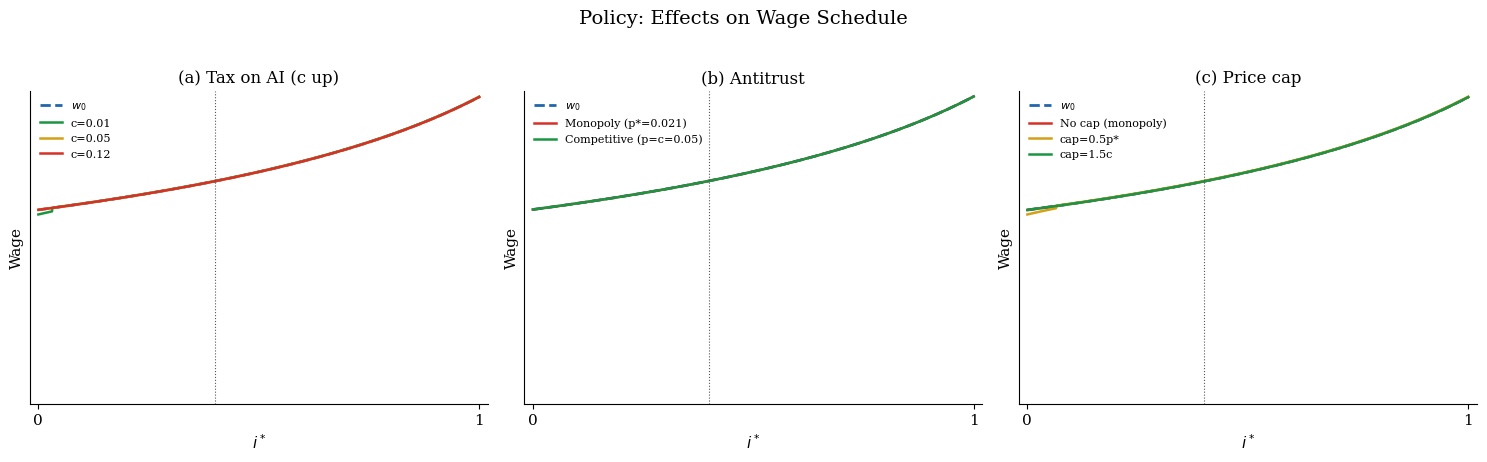

In [62]:
# ── Figure 7: Policy comparative statics ──────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4.5))

# (a) Tax on computation
ax = axes[0]
ax.plot(i_fine, w0_vals, color='#2166ac', lw=2, ls='--', label=r'$w_0$')
tax_colors = ['#1a9641', '#d4a017', '#d73027']
for cc, col in zip(fig7_tax_cs, tax_colors):
    p_c, Q_c, _ = find_monopoly_price(c=cc)
    mask_c = (v_vals >= p_c) & (i_fine < I_star)
    s_c = np.where(mask_c, gamma * M_vals * f_vals, 0.0)
    yb_c = f_vals + s_c
    Yb_c = compute_eq(yb_c); w1_c = wage_from_supply(Yb_c, yb_c)
    ax.plot(i_fine, w1_c, color=col, lw=1.8, label=f'c={cc}')
ax.axvline(I_star, color='#555555', lw=0.8, ls=':')
ax.set_title('(a) Tax on AI (c up)', fontsize=12)
ax.set_xlabel(r'$i^*$'); ax.set_ylabel('Wage')
ax.set_xlim(-0.02, 1.02); ax.set_ylim(0)
ax.set_xticks([0,1]); ax.set_yticks([])
ax.legend(fontsize=8, framealpha=0)

# (b) Antitrust
ax = axes[1]
ax.plot(i_fine, w0_vals, color='#2166ac', lw=2, ls='--', label=r'$w_0$')
ax.plot(i_fine, w1_eq, color='#d73027', lw=1.8, label=f'Monopoly (p*={p_star:.3f})')
mask_comp = (v_vals >= c_mc) & (i_fine < I_star)
s_comp = np.where(mask_comp, gamma * M_vals * f_vals, 0.0)
yb_comp = f_vals + s_comp
Yb_comp = compute_eq(yb_comp); w1_comp = wage_from_supply(Yb_comp, yb_comp)
ax.plot(i_fine, w1_comp, color='#1a9641', lw=1.8, label=f'Competitive (p=c={c_mc})')
ax.axvline(I_star, color='#555555', lw=0.8, ls=':')
ax.set_title('(b) Antitrust', fontsize=12)
ax.set_xlabel(r'$i^*$'); ax.set_ylabel('Wage')
ax.set_xlim(-0.02, 1.02); ax.set_ylim(0)
ax.set_xticks([0,1]); ax.set_yticks([])
ax.legend(fontsize=8, framealpha=0)

# (c) Price cap
ax = axes[2]
ax.plot(i_fine, w0_vals, color='#2166ac', lw=2, ls='--', label=r'$w_0$')
ax.plot(i_fine, w1_eq, color='#d73027', lw=1.8, label='No cap (monopoly)')
cap_colors = ['#d4a017', '#1a9641']
cap_vals = [p_star * fig7_cap_fracs[0], c_mc * fig7_cap_fracs[1]]
cap_labels = [f'cap={fig7_cap_fracs[0]}p*', f'cap={fig7_cap_fracs[1]}c']
for p_cap, col, lbl in zip(cap_vals, cap_colors, cap_labels):
    mask_cap = (v_vals >= p_cap) & (i_fine < I_star)
    s_cap = np.where(mask_cap, gamma * M_vals * f_vals, 0.0)
    yb_cap = f_vals + s_cap
    Yb_cap = compute_eq(yb_cap); w1_cap = wage_from_supply(Yb_cap, yb_cap)
    ax.plot(i_fine, w1_cap, color=col, lw=1.8, label=lbl)
ax.axvline(I_star, color='#555555', lw=0.8, ls=':')
ax.set_title('(c) Price cap', fontsize=12)
ax.set_xlabel(r'$i^*$'); ax.set_ylabel('Wage')
ax.set_xlim(-0.02, 1.02); ax.set_ylim(0)
ax.set_xticks([0,1]); ax.set_yticks([])
ax.legend(fontsize=8, framealpha=0)

fig.suptitle('Policy: Effects on Wage Schedule', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../output/model/fig_comp_statics.png', dpi=150, bbox_inches='tight')
plt.show()

## Fig 8: Empirical f(i) — J-shaped distribution

Task ordering: $i=0$ = most AI-exposed (programmers), $i=1$ = least (manual).

Empirical pattern from CPS kdensity:
- Low $i$ (high exposure): **few** workers — the programmer bump
- Mid $i$ (medium exposure): **many** workers — office/admin mass
- High $i$ (low exposure): **many** workers — manual/service, safe from AI

$$f_J(i) = a + b \cdot (1 - e^{-\kappa i})$$

Starts at $a$ (the small high-exposure group), rises to $a+b$ (the big mid/low-exposure mass).

| Param | What it does |
|---|---|
| `fig8_a` | f(0) — workers at highest exposure. Small = few programmers |
| `fig8_b` | rise — how many more workers at mid/low exposure |
| `fig8_kappa` | speed of rise. Higher = sharper transition |
| `fig8_Istar` | frontier for this figure |

J-shaped f: Y0=2.453, Ybar=2.596, p*=0.1965
f range: [0.50, 2.98]
Automated: 220/800 tasks


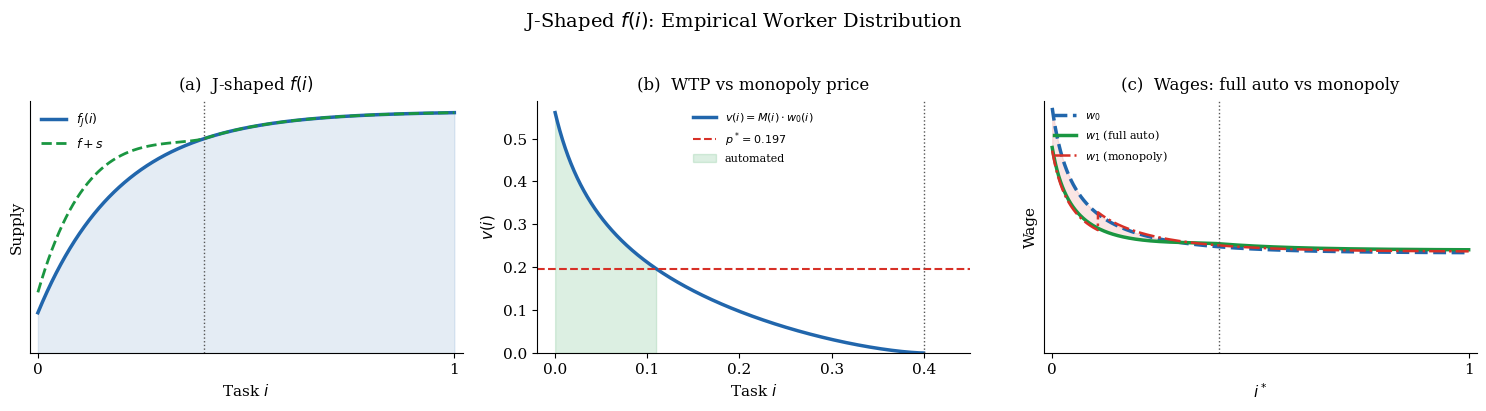

In [63]:
# ╔═══════════════════════════════════════════════════════════════════════════╗
# ║  FIG 8 PARAMETERS — EDIT HERE                                          ║
# ╚═══════════════════════════════════════════════════════════════════════════╝
fig8_a      = 0.5      # f(0): workers at highest exposure (small = few programmers)
fig8_b      = 2.5      # rise: how many more workers at mid/low exposure
fig8_kappa  = 5.0      # speed of rise (higher = sharper J)
fig8_Istar  = 0.4      # AI frontier for this figure
fig8_alpha  = 1.5      # M curvature for this figure
fig8_gamma  = 2.0      # adoption for this figure

# ── f_J(i) = a + b * (1 - exp(-kappa * i)) ──────────────────────────────────
def f_J(i):
    i = np.asarray(i, dtype=float)
    return fig8_a + fig8_b * (1.0 - np.exp(-fig8_kappa * i))

f_j_vals = f_J(i_fine)
Y0_j     = compute_eq(f_j_vals)
w0_j     = wage_from_supply(Y0_j, f_j_vals)

M_j  = M_cap(i_fine, Is=fig8_Istar, a=fig8_alpha)
s_j  = fig8_gamma * M_j * f_j_vals
ybar_j = f_j_vals + s_j
Ybar_j = compute_eq(ybar_j)
w1_j   = wage_from_supply(Ybar_j, ybar_j)

# Also compute v(i) and monopoly for this economy
v_j  = M_j * w0_j
Mf_j = M_j * f_j_vals

def demand_curve_j(p_grid):
    Q_out = np.zeros_like(p_grid)
    for j_idx, p in enumerate(p_grid):
        mask = (v_j >= p) & (i_fine < fig8_Istar)
        Q_out[j_idx] = fig8_gamma * np.trapezoid(Mf_j * mask, i_fine)
    return Q_out

pg_j = np.linspace(0.001, v_j[(i_fine < fig8_Istar) & (v_j > 0)].max() * 1.1, 300)
Qg_j = demand_curve_j(pg_j)
pig_j = (pg_j - c_mc) * Qg_j - F_fixed
p_j = pg_j[np.argmax(pig_j)]
auto_j = (v_j >= p_j) & (i_fine < fig8_Istar)

print(f'J-shaped f: Y0={Y0_j:.3f}, Ybar={Ybar_j:.3f}, p*={p_j:.4f}')
print(f'f range: [{f_j_vals.min():.2f}, {f_j_vals.max():.2f}]')
print(f'Automated: {auto_j.sum()}/{(i_fine<fig8_Istar).sum()} tasks')

# ── Plot ─────────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# (a) f(i) and supply
ax = axes[0]
ax.fill_between(i_fine, 0, f_j_vals, alpha=0.12, color='#2166ac')
ax.plot(i_fine, f_j_vals, color='#2166ac', lw=2.5, label=r'$f_J(i)$')
ax.plot(i_fine, ybar_j, color='#1a9641', lw=2, ls='--', label=r'$f + s$')
ax.axvline(fig8_Istar, color='#555555', lw=1, ls=':')
ax.set_xlabel(r'Task $i$'); ax.set_ylabel('Supply')
ax.set_title('(a)  J-shaped $f(i)$', fontsize=12, pad=8)
ax.set_xlim(-0.02, 1.02); ax.set_ylim(0)
ax.set_xticks([0, 1]); ax.set_yticks([])
ax.legend(fontsize=9, framealpha=0)

# (b) v(i) and monopoly
ax = axes[1]
i_mask = i_fine < fig8_Istar
ax.plot(i_fine[i_mask], v_j[i_mask], color='#2166ac', lw=2.5,
        label=r'$v(i) = M(i) \cdot w_0(i)$')
ax.axhline(p_j, color='#d73027', lw=1.5, ls='--', label=f'$p^*={p_j:.3f}$')
ax.fill_between(i_fine[i_mask], 0, v_j[i_mask],
                where=auto_j[i_mask],
                alpha=0.15, color='#1a9641', label='automated')
ax.axvline(fig8_Istar, color='#555555', lw=1, ls=':')
ax.set_xlabel(r'Task $i$'); ax.set_ylabel(r'$v(i)$')
ax.set_title('(b)  WTP vs monopoly price', fontsize=12, pad=8)
ax.set_xlim(-0.02, fig8_Istar + 0.05); ax.set_ylim(0)
ax.legend(fontsize=8, framealpha=0)

# (c) Wages
ax = axes[2]
ax.plot(i_fine, w0_j, color='#2166ac', lw=2.5, ls='--', label=r'$w_0$')
ax.plot(i_fine, w1_j, color='#1a9641', lw=2.5, label=r'$w_1$ (full auto)')

# Also show monopoly-constrained wages
s_j_mono = np.where(auto_j, fig8_gamma * M_j * f_j_vals, 0.0)
ybar_j_mono = f_j_vals + s_j_mono
Ybar_j_mono = compute_eq(ybar_j_mono)
w1_j_mono = wage_from_supply(Ybar_j_mono, ybar_j_mono)
ax.plot(i_fine, w1_j_mono, color='#d73027', lw=1.8, ls='-.', label=r'$w_1$ (monopoly)')

ax.fill_between(i_fine, w1_j, w0_j, where=(w1_j < w0_j),
                alpha=0.12, color='#d73027')
ax.axvline(fig8_Istar, color='#555555', lw=1, ls=':')
ax.set_xlabel(r'$i^*$'); ax.set_ylabel('Wage')
ax.set_title('(c)  Wages: full auto vs monopoly', fontsize=12, pad=8)
ax.set_xlim(-0.02, 1.02); ax.set_ylim(0)
ax.set_xticks([0, 1]); ax.set_yticks([])
ax.legend(fontsize=8, framealpha=0, loc='upper left')

fig.suptitle('J-Shaped $f(i)$: Empirical Worker Distribution', fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig('../output/model/fig_Jshaped.png', dpi=150, bbox_inches='tight')
plt.show()